━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  走势对比 | 数据源：腾讯财经接口 (前复权 qfq)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▸ 半导体ETF           (sh588200) … ❌  在 data[sh588200] 中找不到 qfqday/day，keys=['day', 'qt', 'mx_price', 'prec', 'version']
▸ 酒ETF             (sh512690) … ✅  640根  2019-09-27 → 2022-05-25
▸ 新能源ETF           (sh516160) … ✅  312根  2021-02-04 → 2022-05-25
▸ 医药ETF            (sh512010) … ✅  640根  2019-09-27 → 2022-05-25
▸ 军工ETF            (sh512660) … ✅  822根  2019-01-02 → 2022-05-25
▸ 黄金ETF            (sh518880) … ✅  640根  2019-09-30 → 2022-05-25
▸ 上证指数             (sh000001) … ✅  822根  2019-01-02 → 2022-05-25


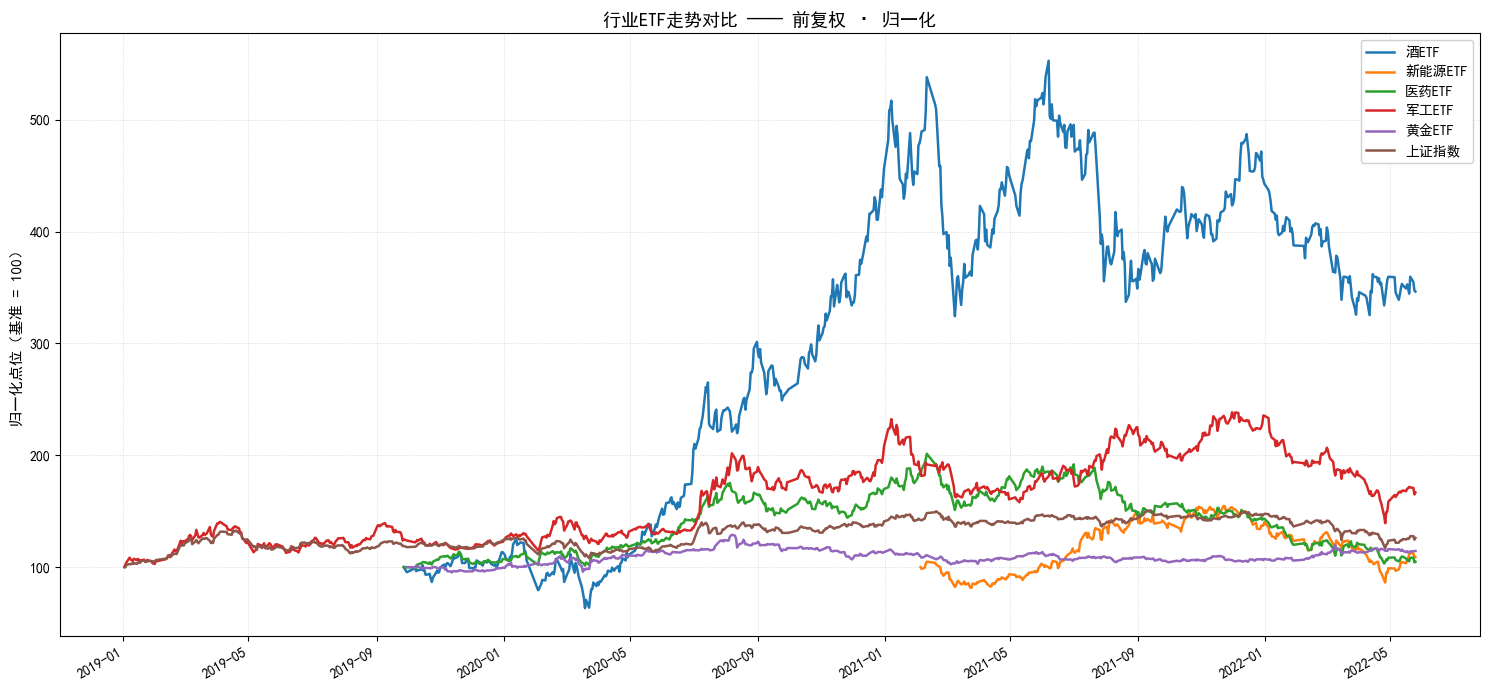

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
多标的走势对比 —— 腾讯接口（前复权 qfq）
用行业ETF / 风格指数代替东方财富板块指数
接口: http://web.ifzq.gtimg.cn/appstock/app/fqkline/get
"""

import time
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# ★ 配置区：把你想对比的板块，替换成对应的 ETF / 指数代码
# ============================================================
# 代码格式：沪市 sh 开头（5/6字头）、深市 sz 开头（0/1/2/3字头）
TARGETS = [
    ("半导体ETF", "sh588200"),    # 588200 半导体
    ("酒ETF",     "sh512690"),    # 512690 白酒
    ("新能源ETF", "sh516160"),    # 516160 新能源
    ("医药ETF",   "sh512010"),    # 512010 医药
    ("军工ETF",   "sh512660"),    # 512660 军工
    ("黄金ETF", "sh518880"),
    ("上证指数", "sh000001"),    # 取消注释 可加基准线
]

START_DATE = "2019-01-01"   # 开始日期（YYYY-MM-DD），接口内尽量裁；最终还会按日期二次过滤
END_DATE   = "2022-05-25"   # 结束日期
COUNT      = 1000             # 先拉足够多根bar，保证覆盖 START~END（ETF历史够长填不满600也无妨）
NORMALIZE  = True            # True = 全部从 100 出发（只看涨幅谁强谁弱，强烈推荐）
DELAY      = 0.35            # 每次请求间隔（秒），降低被拦概率


# ============================================================
# 腾讯接口：前复权日K线
# ============================================================
def fetch_tx_qfq(symbol: str, start: str, end: str, count: int = 600) -> pd.DataFrame:
    """
    从腾讯接口拉 前复权 日K线
    symbol: 'sh588200' / 'sz399006' / 'sh000001' 等
    start/end: 'YYYY-MM-DD'
    返回 DataFrame，index=datetime, columns=[open,close,high,low,volume]
    """
    url = (
        "http://web.ifzq.gtimg.cn/appstock/app/fqkline/get"
        f"?param={symbol},day,{start},{end},{count},qfq"
    )
    r = requests.get(
        url,
        timeout=12,
        headers={
            "Referer": "https://gu.qq.com",
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/120.0.0.0 Safari/537.36"
            ),
        },
    )
    r.raise_for_status()

    # 有些情况下返回带  kline_dayqfq=...  的 js 赋值形式
    text = r.text.strip()
    if text and text[0] != "{":
        # 剥掉 "kline_dayqfq=" 之类前缀
        for ch in ("=", ":"):
            if ch in text[:60]:
                text = text[text.index(ch) + 1 :]
                text = text.lstrip()
                break
    js = json.loads(text)

    # 数据路径：js['data'][symbol]['qfqday'] 或 ['day']
    d = (js or {}).get("data", {})
    if not d:
        raise ValueError(f"返回数据缺少 data 字段: {r.text[:200]}")

    stk = d.get(symbol)
    if not stk:
        # 有时 key 是全大写或带后缀，兜底遍历
        candidates = [k for k in d if symbol.upper() in k.upper()]
        if candidates:
            stk = d[candidates[0]]
        else:
            raise ValueError(f"返回里找不到 symbol={symbol}，keys={list(d.keys())[:10]}")

    # qfqday 优先；没有就用 day
    buf = None
    for key in ("qfqday", "qfqDay", "day"):
        if key in stk and stk[key]:
            buf = stk[key]
            break
    if buf is None:
        raise ValueError(f"在 data[{symbol}] 中找不到 qfqday/day，keys={list(stk.keys())[:10]}")

    # 列顺序: [日期, 开盘, 收盘, 最高, 最低, 成交量/成交额]
    df = pd.DataFrame(buf, columns=["date_str", "open", "close", "high", "low", "vol"])
    df["date"] = pd.to_datetime(df["date_str"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").set_index("date")

    for col in ("open", "close", "high", "low", "vol"):
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 按日期二次裁剪（防止接口多给了尾巴）
    if start:
        df = df[df.index >= pd.Timestamp(start)]
    if end:
        df = df[df.index <= pd.Timestamp(end)]

    return df[["open", "close", "high", "low", "vol"]]


# ============================================================
# 加载 + 绘图
# ============================================================
def main():
    plt.rcParams["font.sans-serif"] = ["SimHei", "WenQuanYi Micro Hei", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

    series_dict = {}  # name -> pd.Series(close)

    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("  走势对比 | 数据源：腾讯财经接口 (前复权 qfq)")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

    for name, code in TARGETS:
        print(f"▸ {name:16s} ({code}) … ", end="", flush=True)
        try:
            df = fetch_tx_qfq(code, START_DATE, END_DATE, COUNT)
            if df.empty or df["close"].dropna().empty:
                print("❌ 空数据")
                continue
            s = df["close"].dropna()
            series_dict[name] = s
            print(f"✅  {len(s)}根  {s.index[0].date()} → {s.index[-1].date()}")
        except Exception as e:
            print(f"❌  {e}")
        time.sleep(DELAY)

    if not series_dict:
        print("\n⚠️  没有拿到任何数据，请检查 TARGETS 里的代码是否正确。")
        return

    # ── 画图 ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 7))

    for name, s in series_dict.items():
        if NORMALIZE:
            y = s / s.iloc[0] * 100.0
            ax.plot(s.index, y, label=name, linewidth=1.8)
        else:
            ax.plot(s.index, s, label=name, linewidth=1.8)

    # 坐标轴格式
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)

    if NORMALIZE:
        ax.set_ylabel("归一化点位（基准 = 100）", fontsize=11)
        ax.set_title("行业ETF走势对比 —— 前复权 · 归一化", fontsize=13)
    else:
        ax.set_ylabel("前复权价格", fontsize=11)
        ax.set_title("行业ETF走势对比 —— 前复权价格", fontsize=13)

    ax.legend(fontsize=10, framealpha=0.92)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [11]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
行业板块指数走势对比
数据源：东方财富原始 HTTP 接口（绕过 akshare）
依赖：pip install requests pandas matplotlib
"""

import time
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────────────────────────────────────────────────────
# ★ 配置：要对比的板块名称（必须与东方财富一致）
# ─────────────────────────────────────────────────────────
BOARD_NAMES = [
    "半导体",
    "白酒",
    "光伏设备",
    "新能源车",
    "医药商业",
]

START_DATE = "20250101"   # YYYYMMDD
END_DATE   = "20250525"
NORMALIZE  = True         # True → 都从 100 出发
DELAY      = 0.35         # 请求间隔（秒）


# ─────────────────────────────────────────────────────────
# Step 1：获取所有行业板块的 {名称: secid}
# ─────────────────────────────────────────────────────────

def get_board_secid_map() -> dict[str, str]:
    """
    返回 {'半导体': '90.BK0474', '白酒': '90.BK0477', ...}
    """
    url = "http://push2.eastmoney.com/getfuturesboardlist"
    params = {
        "pn": 1, "pz": 500,
        "po": 1, "np": 1,
        "fltt": 2, "invt": 2,
        "fid": "f3",
        "fs": "m:90+t:2",       # 90=行业板块
        "fields": "f2,f3,f4,f12,f14",
    }
    r = requests.get(url, params=params, timeout=10, headers={
        "Referer": "http://quote.eastmoney.com/center/BankuaiList.html",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
    })
    r.encoding = "utf-8"
    txt = r.text.strip()

    # 如果返回形如 jQuery([{...}]); 则剥离
    if txt.startswith("jQuery"):
        txt = txt[txt.index("(")+1:]
        txt = txt.rstrip(");")

    js = json.loads(txt)

    mapping = {}
    for item in (js or {}).get("data", {}).get("diff", []):
        name = item.get("f14") or item.get("name")
        code = item.get("f12") or item.get("code")
        if name and code:
            mapping[name] = f"90.{code}"
    return mapping


# ─────────────────────────────────────────────────────────
# Step 2：拉取单个板块的前复权日K线
# ─────────────────────────────────────────────────────────

def fetch_board_kline(secid: str, start: str, end: str) -> pd.DataFrame:
    """
    secid: e.g. "90.BK0474"
    返回 DataFrame[index=datetime, close/open/high/low/volume]
    """
    url = "https://push2his.eastmoney.com/api/qt/stock/kline/get"
    params = {
        "secid": secid,
        "ut": "fa5fd1943c7b386f172d69a3dbfba10b",
        "fields1": "f1,f2,f3,f4,f5,f6",
        "fields2": "f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61",
        "klt": "101",      # 101=日线
        "fqt": "1",        # 1=前复权
        "beg": start,
        "end": end,
        "smplmt": "10000",
    }
    r = requests.get(url, params=params, timeout=15, headers={
        "Referer": f"http://quote.eastmoney.com/center/bk{bkcode_from_secid(secid)}.html",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36",
    })
    r.encoding = "utf-8"
    txt = r.text.strip()

    # 剥离可能的 jQuery 包裹
    if txt.startswith("jQuery"):
        txt = txt[txt.index("(")+1:]
        txt = txt.rstrip(");")

    js = json.loads(txt)
    klines = (js or {}).get("data", {}).get("klines", [])
    if not klines:
        raise ValueError(f"无kline数据（secid={secid}）")

    rows = []
    for line in klines:
        p = line.split(",")
        rows.append({
            "date":   p[0],
            "open":   float(p[1]),
            "close":  float(p[2]),
            "high":   float(p[3]),
            "low":    float(p[4]),
            "volume": float(p[5]),
        })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    return df


def bkcode_from_secid(secid: str) -> str:
    return secid.split(".", 1)[-1] if "." in secid else secid


# ─────────────────────────────────────────────────────────
# 主流程
# ─────────────────────────────────────────────────────────

def main():
    plt.rcParams["font.sans-serif"] = ["SimHei", "WenQuanYi Micro Hei", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

    print("📡 获取行业板块代码映射 …")
    secid_map = get_board_secid_map()
    if not secid_map:
        print("❌ 无法获取板块列表，请检查网络或稍后重试")
        return

    missing = [n for n in BOARD_NAMES if n not in secid_map]
    if missing:
        print(f"\n⚠️  以下名称未匹配：{missing}")
        print(f"   可用名称示例：{list(secid_map.keys())[:8]}")
        print(f"   完整列表：http://quote.eastmoney.com/center/BankuaiList.html\n")

    series_dict: dict[str, pd.Series] = {}

    for name in BOARD_NAMES:
        if name not in secid_map:
            print(f"  ✗ {name} —— 跳过")
            continue
        secid = secid_map[name]
        print(f"  ▸ {name:16s} ({secid}) … ", end="", flush=True)
        try:
            df = fetch_board_kline(secid, START_DATE, END_DATE)
            if df.empty or df["close"].dropna().empty:
                print("空数据")
                continue
            s = df["close"].dropna()
            series_dict[name] = s
            print(f"✅ {len(s)}根  {s.index[0].date()}→{s.index[-1].date()}")
        except Exception as e:
            print(f"❌ {e}")
        time.sleep(DELAY)

    if not series_dict:
        print("\n⚠️  未获取到任何有效数据")
        return

    # ── 绘图 ────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 7))

    for name, s in series_dict.items():
        if NORMALIZE:
            y = s / s.iloc[0] * 100.0
            ax.plot(s.index, y, label=name, linewidth=1.8)
        else:
            ax.plot(s.index, s, label=name, linewidth=1.8)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)

    ax.set_title(
        "行业板块指数走势对比（东方财富原始接口 · 前复权）" +
        (" —— 归一化基准=100" if NORMALIZE else ""),
        fontsize=13
    )
    ax.set_ylabel("归一化点位（起始=100）" if NORMALIZE else "指数点位")
    ax.legend(fontsize=10, framealpha=0.92)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

📡 获取行业板块代码映射 …


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [26]:
import akshare as ak
pd.set_option('display.max_rows', None) # 显示所有行
pd.set_option('display.max_columns', None) # 显示所有列
ak.stock_board_industry_name_ths()['name'].values.tolist() 

['半导体',
 '白酒',
 '白色家电',
 '保险',
 '包装印刷',
 '厨卫电器',
 '电池',
 '电机',
 '电力',
 '电网设备',
 '多元金融',
 '电子化学品',
 '房地产',
 '风电设备',
 '非金属材料',
 '服装家纺',
 '纺织制造',
 '工程机械',
 '光伏设备',
 '贵金属',
 '轨交设备',
 '港口航运',
 '公路铁路运输',
 '钢铁',
 '光学光电子',
 '工业金属',
 '环保设备',
 '环境治理',
 '互联网电商',
 '黑色家电',
 '化学纤维',
 '化学原料',
 '化学制品',
 '化学制药',
 'IT服务',
 '机场航运',
 '军工电子',
 '军工装备',
 '家居用品',
 '计算机设备',
 '金属新材料',
 '教育',
 '建筑材料',
 '建筑装饰',
 '零售',
 '旅游及酒店',
 '美容护理',
 '煤炭开采加工',
 '贸易',
 '农产品加工',
 '农化制品',
 '能源金属',
 '汽车服务及其他',
 '汽车零部件',
 '汽车整车',
 '其他电源设备',
 '其他电子',
 '其他社会服务',
 '软件开发',
 '燃气',
 '塑料制品',
 '食品加工制造',
 '生物制品',
 '石油加工贸易',
 '通信服务',
 '通信设备',
 '通用设备',
 '文化传媒',
 '物流',
 '消费电子',
 '小家电',
 '小金属',
 '橡胶制品',
 '元件',
 '医疗服务',
 '医疗器械',
 '饮料制造',
 '油气开采及服务',
 '影视院线',
 '游戏',
 '银行',
 '医药商业',
 '养殖业',
 '自动化设备',
 '综合',
 '证券',
 '中药',
 '专用设备',
 '造纸',
 '种植业与林业']

📡 正在获取同花顺行业板块名称列表 …
   共 90 个行业板块

  ▸ 半导体 … 

  0%|          | 0/3 [00:00<?, ?it/s]

✅ 554根  2024-02-01→2026-05-25
  ▸ 白酒 … 

  0%|          | 0/3 [00:00<?, ?it/s]

✅ 554根  2024-02-01→2026-05-25
  ▸ 光伏设备 … 

...

✅ 554根  2024-02-01→2026-05-25
  ▸ 通信设备 … 

  0%|          | 0/3 [00:00<?, ?it/s]

✅ 554根  2024-02-01→2026-05-25
  ▸ 电网设备 … 

  0%|          | 0/3 [00:00<?, ?it/s]

✅ 554根  2024-02-01→2026-05-25


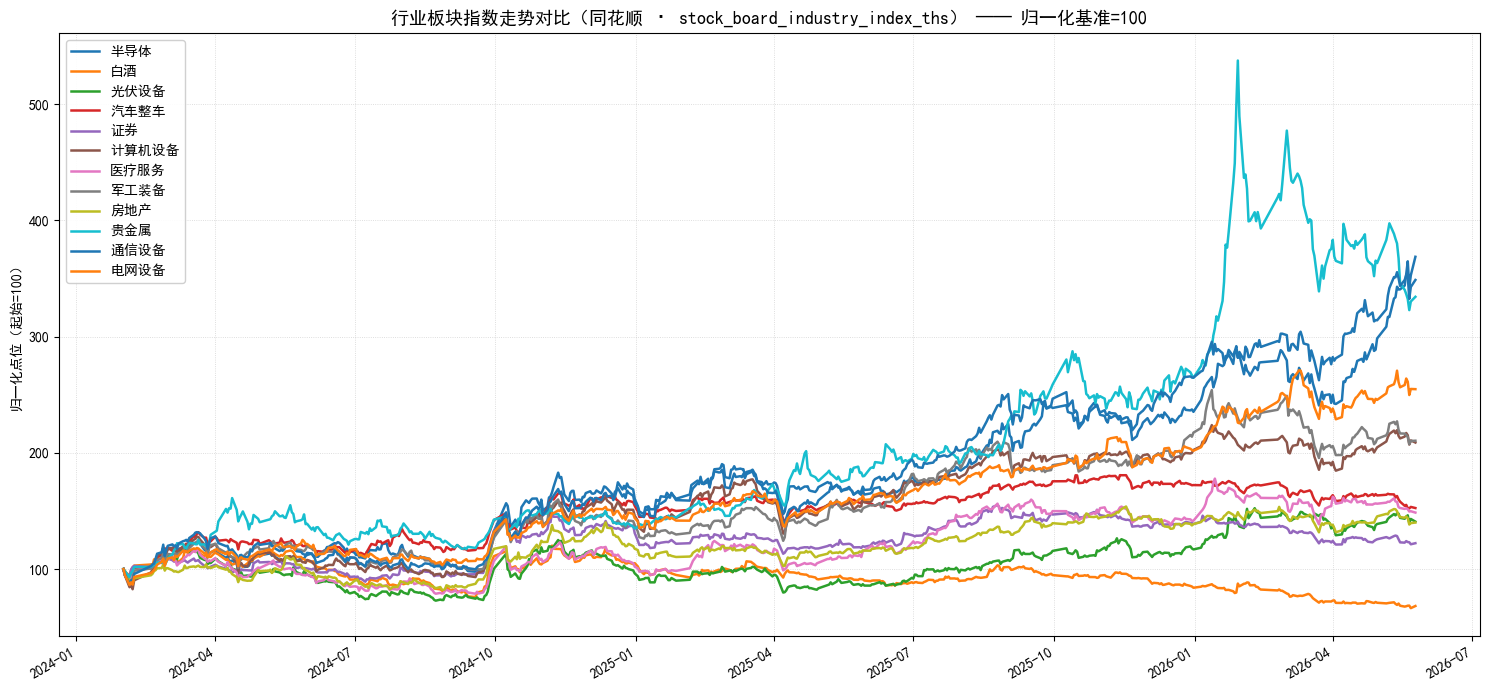

In [33]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
多板块指数走势对比 —— 使用 akshare 同花顺接口
接口：ak.stock_board_industry_name_ths()  -> 列出行业
       ak.stock_board_industry_index_ths() -> 行业板块指数日频K线
"""

import akshare as ak
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import warnings

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────
# ★ 配置区
# ──────────────────────────────────────────────────────────

# 同花顺行业板块名称（必须精确匹配，下方第一次运行会打印全部可选名称）
INDUSTRIES = [
    "半导体",
    "白酒",
    "光伏设备",
    "汽车整车",
    "证券",
    "计算机设备",
    "医疗服务",
    "军工装备",
    "房地产",
    "贵金属",
    "通信设备",
    "电网设备",
]
# INDUSTRIES =  ak.stock_board_industry_name_ths()['name'].values.tolist() 
START_DATE = "2024-02-01"   # 也接受 "20250101"
END_DATE   = "2026-05-25"

NORMALIZE = True   # True = 全部从 100 出发，只看涨幅差异（推荐）
SHOW_NAMES = True  # 首次运行建议 True：打印全部可选行业名称，方便你核对

# ──────────────────────────────────────────────────────────

def get_valid_industry_names() -> set:
    """获取同花顺所有行业名称集合（用于校验）"""
    df = ak.stock_board_industry_name_ths()
    # 这个接口返回的列一般是 '板块名称' 或 'name'
    col = df.columns[0]
    return set(df[col].astype(str).str.strip())


def fetch_industry_index(symbol: str, start: str, end: str) -> pd.DataFrame:
    """
    拉取单个同花顺行业板块指数日线
    返回 DataFrame with columns at least ['日期','收盘价']
    """
    df = ak.stock_board_industry_index_ths(
        symbol=symbol,
        start_date=start.replace("-", ""),
        end_date=end.replace("-", ""),
    )
    if df is None or df.empty:
        return pd.DataFrame()

    # 统一日期列
    date_col = "日期"
    if date_col not in df.columns:
        # 防御：有些环境下列名可能不同
        for c in df.columns:
            if "日期" in c or "date" in c.lower():
                date_col = c
                break

    df = df.copy()
    df["_date"] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=["_date"]).sort_values("_date")

    # 找收盘价列
    close_col = None
    for c in ("收盘价", "close", "收盘"):
        if c in df.columns:
            close_col = c
            break
    if close_col is None:
        raise KeyError(f"[{symbol}] 找不到收盘价列，当前列={list(df.columns)}")

    df[close_col] = pd.to_numeric(df[close_col], errors="coerce")
    out = df.set_index("_date")[[close_col]].rename(columns={close_col: "close"})
    out = out[out.index >= pd.Timestamp(start)] if start else out
    out = out[out.index <= pd.Timestamp(end)] if end else out
    return out


def main():
    # ── 1. 校验/提示可用行业名称 ──────────────────────────
    print("📡 正在获取同花顺行业板块名称列表 …")
    valid = get_valid_industry_names()
    print(f"   共 {len(valid)} 个行业板块\n")

    # if SHOW_NAMES:
    #     print("── 同花顺行业板块名称（复制粘贴用）──")
    #     for n in sorted(valid):
    #         print(" ", n)
    #     print("────────────────────────────────────\n")

    invalid = [x for x in INDUSTRIES if x not in valid]
    if invalid:
        print(f"⚠️  以下名称不在同花顺行业列表中：{invalid}")
        print("   请用上方打印的名称精确修改 INDUSTRIES 列表\n")

    active = [x for x in INDUSTRIES if x in valid]
    if not active:
        print("❌ 没有可用的行业名称，请修正 INDUSTRIES")
        return

    # ── 2. 拉数据 ────────────────────────────────────────
    plt.rcParams["font.sans-serif"] = ["SimHei", "WenQuanYi Micro Hei", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

    series_dict = {}

    for name in active:
        print(f"  ▸ {name} … ", end="", flush=True)
        try:
            df = fetch_industry_index(name, START_DATE, END_DATE)
            if df.empty:
                print("❌ 空数据")
                continue
            s = df["close"].dropna()
            series_dict[name] = s
            print(f"✅ {len(s)}根  {s.index[0].date()}→{s.index[-1].date()}")
        except Exception as e:
            print(f"❌ {e}")
        time.sleep(0.3)

    if not series_dict:
        print("\n❌ 没有拿到任何数据")
        return

    # ── 3. 画图 ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 7))

    for name, s in series_dict.items():
        if NORMALIZE:
            y = s / s.iloc[0] * 100.0
            ax.plot(s.index, y, label=name, linewidth=1.8)
        else:
            ax.plot(s.index, s, label=name, linewidth=1.8)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)

    ax.set_title(
        "行业板块指数走势对比（同花顺 · stock_board_industry_index_ths）" +
        (" —— 归一化基准=100" if NORMALIZE else ""),
        fontsize=13
    )
    ax.set_ylabel("归一化点位（起始=100）" if NORMALIZE else "指数点位")
    ax.legend(fontsize=10, framealpha=0.92)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.55)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
ak.fund_name_em() 

In [41]:
ak.fund_portfolio_hold_em(symbol="000011", date="2026")

,序号,股票代码,股票名称,占净值比例,持股数,持仓市值,季度
0,1,300750,宁德时代,8.06,75.92,30249.94,2026年1季度股票投资明细
1,2,300408,三环集团,3.76,266.88,14104.61,2026年1季度股票投资明细
2,3,688041,海光信息,3.69,65.86,13847.18,2026年1季度股票投资明细
3,4,300274,阳光电源,2.76,68.70,10357.21,2026年1季度股票投资明细
4,5,300502,新易盛,2.75,23.65,10306.84,2026年1季度股票投资明细
5,6,601899,紫金矿业,2.64,303.24,9922.01,2026年1季度股票投资明细
6,7,002371,北方华创,2.55,21.42,9574.74,2026年1季度股票投资明细
7,8,000977,浪潮信息,2.53,169.08,9482.28,2026年1季度股票投资明细
8,9,300124,汇川技术,2.35,131.69,8823.23,2026年1季度股票投资明细
9,10,300548,长芯博创,2.24,54.84,8398.75,2026年1季度股票投资明细


In [44]:
ak.fund_report_stock_cninfo(date="20260331")

,序号,股票代码,股票简称,报告期,基金覆盖家数,持股总数,持股总市值
0,1,300750,宁德时代,2026-03-31,2335,399291123,16037690.22
1,2,300308,中际旭创,2026-03-31,1860,229794279,13083991.99
2,3,300502,新易盛,2026-03-31,1484,257119104,11384244.06
3,4,601899,紫金矿业,2026-03-31,1472,2135493139,6987333.55
4,5,600519,贵州茅台,2026-03-31,1347,65029657,9429300.27
5,6,601318,中国平安,2026-03-31,1044,892756678,5069072.42
6,7,000333,美的集团,2026-03-31,910,454192575,3467760.31
7,8,600036,招商银行,2026-03-31,786,898055440,3531153.99
8,9,300274,阳光电源,2026-03-31,732,183206978,2762028.40
9,10,002475,立讯精密,2026-03-31,685,443226107,2183331.80


In [46]:
ak.fund_stock_position_lg()

,date,close,position
0,2017-12-04,4018.86,89.25
1,2017-12-08,4003.38,90.57
2,2017-12-15,3980.86,90.43
3,2017-12-22,4054.60,90.27
4,2017-12-29,4030.85,90.34
5,2018-01-05,4138.75,90.49
6,2018-01-12,4225.00,90.34
7,2018-01-19,4285.40,90.57
8,2018-01-26,4381.30,90.88
9,2018-02-02,4271.23,90.30
